In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

In [ ]:
from openai import OpenAI
client = OpenAI(api_key=api_key)

# ── Basic streaming (print to terminal) ──
stream = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user",
               "content": "Count 1 to 10 slowly"}],
    stream=True,   # ← one line to enable

)

for chunk in stream:
    token = chunk.choices[0].delta.content

    if token is not None:
        print(token, end="", flush=True)

# ── Async streaming (for FastAPI) ──
from openai import AsyncOpenAI
async_client = AsyncOpenAI(api_key=api_key)

async def stream_response(question: str):
    full_text = ""
    stream = await async_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role":"user","content":question}],
        stream=True,
    )
    async for chunk in stream:

        token = chunk.choices[0].delta.content or ""
        full_text += token
        yield token  # send to frontend live


    # full_text now has complete response
    save_to_history(full_text)

Sure! Here we go:

1...  
2...  
3...  
4...  
5...  
6...  
7...  
8...  
9...  
10...  

Take your time and enjoy the counting!

## What streaming solves:

Without stream=Ture, you wait for the FULL response, then see it all at once. With streaming, each word appears the moment the model generates it--exactly like ChatGPT typing.


```python
stream = client.chat.completions.create(
    model="gpt-4o-mini",
    message=[{"role":"user","content":"count 1 to 10 slowly"}],
    stream = True, # <- this is the only new thing
)
```

This is like general purpose API call, the only difference is `stream= True`.

Without is -> You get one big response object back. With it -> you get a stream object, which is like a pipe that keeps delivering small pieces one by one.

``for chunk in stream:``

Each chunk is one tiny delivery from the model -- usually just one word, or sometimes even just one letter.

``token = chunk.choices[0].delta.content``

* It is slightly different form `choices[0].message.content` from normal calls.
* In streaming it changes slightly:
 - `message` becomes `delta` -- because it's only the new bit (delta=change).
 - So `delta.content` = the tiny new piece of textt in this chunk.



```python 
if token is not None:
    print(token,end="",flush=True)

```

- if token is not None -- the very last chunk the model sends has `None` as content(it's just a signal that streaming is finished).This check skips that empty final chunk.

- `end=""` -- normaly `print()` adds a new line after each thing it prints.`end=""` stops that,so all tokens print on the same line.

-`flush=True` -- forces the terminal to show the text immediately. Without this,Python might wait and batch the output, ruining the live effect.

-`Result`: Each word appears on screen the moment it arrives, one after another-- the typing effect.

## Part 2: Async Streaming(for FastAPI)

This is the same idea but written for FastAPI, whihc needs `async` code.

What is `async`?

Imagine a waiter at a restaurant. A normal(sync) waiter takes your order, goes to the kitchen, and stands there waiting until your food is ready-- ignoring all other tables.


An async waiter takes your order, goes to the kitchen, submits it, and while the food is being cooked goes to serve other tables. When food is ready, he comes back.

`async` in Python works the same way-- while waiting  for the AI to respond, your server can handle other users' requests. This is essential for a real API.

```Python

from openai import AsyncOpenAI
async_client = AsyncOpenAI(api_key=" ")
```

Same as `OpenAI` but the async version. Use this indside FastAPI.


```Python
async def stream_response(question:str):
```
`async def` means this is an sync function. Inside it you can `await` things(pause and let other things run while waiting).

```Python
full_text=""
stream = await async_client.chat.completions.create(
    ...
    stream=True,
)

```
`await` means--"start this, and while waiting for the first chunk, go handle other requests."
When the first chunk arrives, come back here.

```Python
async for chunk in stream:
    token = chunk.choices[0].delta.content or ""
    full_text += token
    yield token
```


* `async for` -- same as `for` but async-friendly. Each iteration waits for the next chunk without freezing the server.
--`or ""` -- if `delta.content` is `None` (last empty chunk), use `""` instead. Cleaner than an `if` check.
--`full_text += token` -- stich every token together to build the complete response. 
-- `yield token` -- instead of `return`, this sends each token to whoever called this function immediately as it arrives. In FastAPI, This sends it to the browser live.

```Python
save_to_history(full_text)
```
After the loop finishes, `full_text` contains the entire response. Save it to your conversation history so the model "remembers" what it said.

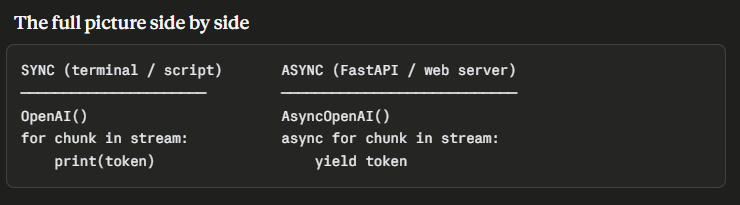








# Zero-shot prompting -- ask clearly, get better answers

### Zero-shot means you give NO examples -- just a well-written instruction. The single biggest skill in prompt engineering is writting a clear, specific, role-based prompt instead of vague one.


`Weak Prompts`:
 Summarize this text.
 {text}


 `Strong Prompt`:

 You are a professional business analyst.
 Summarize the following text for a busy executive who has 30 seconds to read it.

 Rules:
 - max 3 bullet points.
 - Start each bullet with a bold keyword.
 - No jargon.
 - Focus on business impact only 

 Text:
 {text}

 STRONG -> 3 Clean bullets, keyword-led, executive-ready.

## Few-Shot prompting--teach by example:

Few-shot means you show2-5 examples of the exact input/putput pattern you want before asking your real question. The model learns the pattern from examples far better than from description alone.

```Python

SYSTEM_PROMPT ="""
Classify customer reviews as POSIVTIVE, NEGATIVE, or NEUTRAL. Reply with only the label - nothing else.

# Examples (few-shot):

Review: "Fast shipping, love it!"
Label: POSITIVE

Review:" Broke after 2 days, Awful."
Label: NEGATIVE

Review: " It arrived. Does the job."
Label: Neutral
"""

# Now ask the real question
user_message ="""
Review: "Decent quality but overpriced."
Label:"""

response = client.chat.completion.create(
    model="gpt-4o-mini",
    messages=[
        {"role":"System","content":SYSTEM_PROMPT},
        {"role":"user","content":user_message},
    ],
    temperature=0, #0 = fully factual
)
```

`show,don't just tell` -- instead of "classify as positive/negative/neutral", You show what that looks like for real examples.

`3-5 examples` is usually enough. Cover edge cases -- include one ambiguous example (like NEUTRAL) so the model knows what to do with them.

`Match the format exactly` -- Your examples use "Review:/Label:" format,so your real question uses the same format. The model completes the pattern.

`temperature=0`--for classification tasks alaways use 0. You want the same answer every time, not creative variation.

`When to use`-- whenever you need consistent formatting, specific tone,or a pattern the model doesn't naturally follow. Works better than describing the pattern in words.

# Chain of Thought -- make the model think step by step.

For complex problems(math, logic, multi-step reasoning), asking the model to "think step by step" before answering dramatically improves accurarcy. You're forcing it to show its work.

### Without Chain of Thought:
` A store sells apples for $0.50 each and oranges for $0.75 each. Sarah buys 4 apples and 3 oranges. She pays with a $5 note. How much change does she get?`

`Answer`

Model often answers: "$0.5"-- wrong, jumped straight to a guess


# With chain of Thought prompting ---
` A store sells apples for $0.50 each and oranges for $0.75 each. Sarah buys 4 apples and 3 oranges. She pays with a $5 note. How much change does she get?`

`Think through this step by step before giving the final answer.`


#### Three ways to trigger chain of thought:

* "Think step by step." <- simplest, works most of the time.
* " Before answering, reason through the problem carefully."
* "Let's work through this step by step:
   Step 1: ....."   <- start the reasoning yourself, model continues.






# ReAct pattern -- the loop powers AI Agents

ReAct = Reason + Act. The model alternates between thinking about what to do (Thought), doing something (Action), and observing the result (Observation) -- until it reaches a final answer. this is the backbone of every AI agent.


SYSTEM_PROMPT ="""
You are an AI assistant with tools. Solve problems using this loop:
Solve problems using this loop:

Thought: reason about what to do next

Action: tool_name(argument)

Observation: [result of the action]

...report until done....
Final Answer: your conclusion

Available tools:

- search(query) -> web search
- calculator(expr) -> evaluates math
- get_weather(city) -> current weather

"""
````
# What the model produces:

#------------------------------

# User: "What is 15% tip on $47.80?"

# 

# Thought: i need to calculate 15% 

# of 47.80

# Action:calculator(47.80*0.15)
# Observation: 7.17

# Action: calculator(47.80 + 7.17)
# Observation: 54.97

# Final Answer: The 15% tip is $7.17,
# making the total $54.97.

# Your code parses "Action:" lines
# and actually runs the tools

# Output formatting-- get structured, usable data.

By default the model returns free-form text. In real apps you need structured data -- JSON, markdown, tables, XML. Specify the exact format and the model follows it reliably.


```Python 

# ---- Force JSON Output ----

prompt ="""
Extract the following from this job ad. 
Return ONLY valid JSON. No explanation.
No markdown code fences. Just the JSON.

Required format:
{

"job_title":"string",
"compnay":"string",
"salary_range":"string or null",
"required_skills": ["skill",....],
"remote":true or false
}

Job ad:
{job_ad_text}
"""

# Always parse and validate output

import json 
raw = response.choices[0].message.content

try:
    data = json.loads(raw)
    # Use data["job_title"],etc.
except json.JSONDecodeError:
    # retry or ask model to fix it 
    pass


# ---Or use response_format param ---
response= client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[....],
    response_format = {"type":"json_object"},
    # gurantees valid JSON output
)
```

OUTPUT -> {"job_title":"ML Engineer","company":"Acme","Salary_range":"$120k-$150k","required_skills":["Python","PyTorch"],"remote":true}


JSON output + Pydantic validation = bulletproof structured data from any LLM. This pattern is used in every production AI pipeline.




- `Show the exact schema` -- paste the JSON structure you want, field by field, with types. The model copies it eaxactly.

- `No markdown code fences` -- without this, the model wraps JSON in ```json...``` which breaks `json.loads()` . Always include this instruction.

- `Always use try/except` -- even well-instructed models occasionally produce slighlty malformed JSON. Always wrap parsing in error handling.

- `response_format json_object` -- OpenAI's built-in JSON mode. Guarantees valid JSON. Cleaner than prompt-based JSON. Use when available.

- `Pydantic for validation`-- after parsing JSON, run it through a Pydantic model to validate types, required fields, and ranges automatically.


How to simply retry the same request for a valid json input:

```Python
import json 
def get_json_response(prompt:str,retries:int=3) -> dict:
    for attempt in range(retries):
        raw = client.chat.completions.create(
            model="gpt-4o-mini",
            messages = [{"role":"user","content":prmpt}],
        ).choices[0].message.content


        try:
            return json.loads(raw) # Worked -> return immediately

        except json.JSONDecodeError:
            print(f"Attempt {attempt +1} failed. Retrying...")
            # loop continues to next attempt

    
    raise Exception("Model failed to return valid JSON after 3 attempts.")
    ```


    # Option 2-- Ask the model to fix its own broken JSON

    ```Python
    import json 
    def get_json_with_fix(prompt:str)->dict:
        # First attempt
        raw = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role":"user","content":prompt}],

        ).choices[0].message.content

        try:
            return json.loads(raw) # worked first time
        except json.JSONDecodeError:
            # Send the broken output back and ask the model to repair it 
            fix_prompt = f""" The following text is supposed to be valid JSON but it has a syntax error. Fix it and return ONLY the corrected JSON. No explanations. No markdown fences. Just the raw JSON.

            Broken JSON:
            {raw}"""

                    fixed_raw = client.chat.completions.create(
                        model="gpt-4o-mini",
                        messages=[{"role":"user","content": fix_prompt}],
                        ).choices[0].message.content

                    return json.loads(fixed_raw) # parse the fixed version 
```

# Option 3 -- Strip common formatting mistakes first

```Python
import json
import re

def clean_and_parse(raw:str) -> dict:
    # Models often wrap JSON in ```json... ``` -- strip that
    raw = re.sub(r"```json|```","",raw).strip()

    # Sometimes there's text before the first {- remove it 

    start = raw.find("{")
    if start >0:
        raw = raw[start:]
    
    return json.loads(raw)
```

# Option 4 -- Use `response format` skip all of this

```Python 
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role":"user","content":prompt}],
    response_format={"type":"json_object"}, # guarantees valid JSON
)

data = json.loads(response.choices[0].message.content)
# No Try/except needed -- will always be valid JSON

```


# Langchain Rag:

## Loaders

A loader reads your source files and converts them into LangChain Document objects. Each Document has two things: page_content(the text) and metadata (source, page number, etc.)


```Python
from langchain_community.document_loaders import (
    PyPDFLoader, # Pdf files
    TextLoader,  #.txt files
    WebBaseLoader, # Web pages
    CSVLoader, #CSV files
    DirectoryLoader, # entire folder
)

# ---- Load a PDF------

loader = PyPDFLoader("handbook.pdf")
docs=loader.load()

# docs = list of Document objects
# one Document per page


# --- Load a web page---

loader = WebBaseLoader(
     "https://docs.python.org/3/tutorial/"

)
docs = loader.load()

# --- what a Document looks like---
print(docs[0].page_content) # The text
print(docs[0].metadata)

# {'source':'handbook.pdf','page':0}
```

- `Document` -- Langchain's universal wrapper for any content. Always has `page_content(text)` and `metadata`(where it came from).

- `PyPDFLoader` -- splits PDFs page by page automatically. Each page becomes one Document.

-` WebBaseLoader` -- scapes a URL and turns its text content into Documents. Powerful for knowledge basaes with many files.
-`DirectoryLoader` -- loads an entire forlder. Use glob to filter by file type. Powerful for knowledge bases  with many files.

-`metadata`-- automatically tracks the source file and page. This is what allows you to cite sources in your final answer.




# Text Splitters -- cut documents into chunks

```You can't embed a 200-page PDF as one block-- it's too big for the context window and too general to retrieve meaningfully. Splitting cuts documents into small, overlapping chunks that can be searched precisely.```

```Python
from langchain.text_splitter import (
    RecursiveCharacterTextSplitter,
)

splitter = RecursiveCharacterTextSplitter(
    chunk_size =500,  # Chars per chunk
    chunk_overlap= 50, # Overlap between chunks  

    length_function = len,
    separators=["\n\n","\n"," ",""],
)

# Split the loaded documents
chunks = splitter.split_documents(docs)

print(f"Documents: {len(docs)}")
print(f"Chunks: {len(chunks)}")

# Documents: 5 -> Chunks: 47
# Each chunk still has metadata
print(chunks[0].page_content)
print(chunks[0].metadata)

# {'source':'handbook.pdf','page':0}

# -- Why overlap matters ---
# Chunk 1: "... The return policy allows"
# Chunk 2: "policy allows 30 days from..."

#     ^ Overlap keeps context intact 
```

- `chunk_size` -- how many characters per chunk. 500-1000 is typical. Too small = loses context. Too
big = less precise retrieval.

-`chunk_overlap`--how many characters repeat between adjacent chunks. Prevents a sentence being cut in half accross  two chunks, losing its meaning.

-`separators` -- tries to split on double newlines first(paragraphs), then single newlines, then  spaces. Keeps sentences intact wherever possible.

-`Metadatapreserved`-- each chunk inherits the source and page from its parent Document. You can always trace an answer back to its source.

-`RecursiveCharacterTextSplitter`--the default choice for almost every use case. It's smart about finding natural break points in text.




# Embeddings -- turn chunks into searchable numbers

```Embedding convert each chunk into a list of numbers(a vector) that represents its meaning. Similar chunks get similar vectors. LangChain wraps the OpenAI embeddings API so you don't call it manually.```


- `OpenAIEmbeddings`--wraps the OpenAI embeddings API. Pass this object to the vector store and it handles embedding automatically.

-`embed_query`--embed a single string. Used at query time for the user's question.

-`embed_documents`--embed a list of strings.Used at ingest time for your chunks.

-`You rarely call these directly`--the vector store(next lesson) calls them automatically. You just pass the embeddings object.

-`HuggingFaceEmbeddings`--free, runs locally, no API key. Slightly lower quality than OpenAI but great for learning and testing.

```Python

from langchain_openai import OpenAIEmbeddings

# ----- Set up the embedding model -----

embeddings = OpenAIEmbeddings(
    model ="text-embedding-3-small",
    openai_api_key=open_ai_api_key,

)

# ---- Embed a single string (manual)-----
vector = embeddings.embed_query(
    "what is the return policy?"
)
print(f"Vector length: {len(vector)}")
# Vector length: 1536


# ---- Embed a list of texts (manual) ----
texts = ["Return policy", "Shipping info"]
vectors = embeddings.embed_documents(texts)

# returns [[....1536 floats.....],[.....]]

# -- In practice you don't call these--
# The vector store calls them for you.
# Just pass the embeddings object.

# --- Free alternative (no API cost) ----
from langchain_community.embeddings import (
    HugginFaceEmbeddings,
)
free_embeddings = HuggingFaceEmbeddings(
    model_name ="all-MiniLM-L6-v2"
)
```


# Vector store -- store and search your embeddings

A vector store saves all your chunk vectors and lets you search them by similarity. Chroma runs locally -- no sign-up needed. In production you switch to pinecone or pgvector with one line change.

```Python 
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(
    model ="text-embedding-3-small"
)



# --- Build store from chunks (one time) ----
vectorstore = Chroma.from_documents(
    documents=chunks, # your split chunks
    embedding = embeddings, # Embed model
    persist_directory ="./chroma_db",
)

# Embed every chunk  + saves to disk

# ---- Load existing store (next run) ---
vectorstore = Chroma(
    persist_directory="./chroma_db",
    embedding_function = embeddings,
)

# ---- Search manually ------

results = vectorstore.similarity_search(
    query="What is the return policy?",
    k=3, # return top 3 matches
)

for doc in results:
    print(doc.page_content)
    print(doc.metadata["source"])

```

-`Chroma.from_documents` -- the most important line. It embeds every chunk and stores the vectors. Do this once. Never again unless document change.
-`persist_directory`-- saves the vector store to disk so you don't re-embed on every run.Load it with Chroma(...) on subsequent runs.
-`similarity_search` -- embed the query, find the k most similar chunks. Returns Documents with their metadata intact.
-`k=3` -- how many chunks to retrieve. 3-5 is typical. Too few = missing context. Too many = noisy prompt.
-`Swap to Pinecone in 1 line`-- just replace Chroma with Pinecone. The rest of your code stays identical. That's the power of LangChain's abstraction.



# Retriever -- the bridge between search and generation:

A retriever wraps the vector store and gives LangChain a standard interface to fetch relevant documents. It's what plugs into the RAG chain in the next lesson.


```Python
#--- Basic retriever-----
retriever = vectorstore.as_retriever( """ this converts your chroma vector store into a retriever object.It's just a wrapper(is a code layer--such as a function, method, or class-- that encloses another piece of code to modify its behavior, extend its functionality, or simplify its interface wihtout altering the original source code). The underlying data stays in Chroma-- the retriever is just the interface on to """ 
    search_type="similarity", ## tells the retriever which algorithm to use when searching.
    search_kwargs={"k":4}, # means how many chunks to return. You get 4 chunks back from the vector store. These  4 chunks get stuffed into your prompt as context.

)

# Use it manually
docs = retriever.invoke(#  it first embed the question then compare against all stored chunk vectors using cosine similarity then it rank score.
    "What is the return policy?"
)

# ----MMR retriever (more diverse results) ----
retriever_mmr = vectorstore.as_retriever(
    search_type = "mmr", # max marginal relevance

    search_kwargs={
        "k":4,
        "fetch_k":20, # fetch 20, pick best 4
    }
)

# MMR avoids returning 4 nearly-identical chunks
# Great when your docs have repeated content


#----Filter by metadata----

retriever_filtered = vectorstore.as_retriever(
    search_kwargs={
        "k":3,
        "filter":{"source":"handbook.pdf"},

    }
)

# Only retrieves from the handbook.pdf
# Useful when you have multiple doc types.

```
-  `as_retriever()` -- converts your vector store into a standard retriever LangChain chains can plug into.
- `search_type="similarity"`-- returns the top k most similar chunks. The default. Good for most cases.
- `search_type="mmr"`-- Max Marginal relevance. Fetches 20 candidates, then picks the 4 most relevant AND most different from each other. Reduces repetition.
- `filter` -- restrict retrieval to specific metadata values. Useful when you have multiple document sources and want to search only one.
- `retrieval.invoke()`-- call it directly to test what it retrieves before connecting it to the full chain. Always test this step in isolation first.



# RAG Chain -- connect retrieval to generation

The RAG chain ties everything together. It takes the user's question, retrieves relevant chunks, injects them into a prompt, and calls the LLM -- all in one.invoke() call.


```Python
from langchain_openai import ChatOpenAI
from langchain.chains import RetrievalQA
from lnagchain.prompts import PromptTemplate

llm = ChatOpenAI(model="gpt-4o-mini",
                temperature=0.2)

# --- Custom RAG Prompt ----

RAG_PROMPT = PromptTemplate(
    template="""
    You are a helpful assistant.
    Answer using only the context below.
    If the answer is not in context, say:
    "I don't have that information."
    Never make up facts.

    Context: {context}
    Question: {question}
    Answer:""",
    input_variables=["context","question"],
)

# ----Build the RAG chain ----
rag_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever = retriever,
    chain_type_kwargs={"prompt":RAG_PROMPT},
    return_source_documents=True,
)

# --- Ask a question -----
result = rag_chain.invoke(
    {"query":"What is the return policy?"}
)
print(result["result"])
print(result["source_documents"])


```
- `PromtTemplate` -- Your custom RAG prompt. Has two placeholders:{context}(retrieved chunks) and {question}(user query). LangChain fills them automatically.
-`RetrievalQA` -- the chain that glues retriever + prompt +LLM. One call does:embed query -> retrieve chunks -> fill prompt -> call LLM  -> return answer.

-`return_source_documents=True` -- the response includes which chunks were used. Essential for citing sources and debugging bad answers.
-`result["result"]`--the LLM's final answer as a string.
-`result["source_documents"]`--the chunks that generated the answer. Show these to users as references or check them to debug wrong answers.



# Full RAG app --everything in one file.

The complete pipeline from raw PDF to working Q&A system. Compare this with your manual retrieval.py-- same concepts, a fraction of the code.

```Python

import os
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import Chroma
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate

DB_PATH ="./chroma_db"
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)


def build_or_load_store(pdf_path: str): # Takes pdf as input. Returns a chroma vector store.
    if os.path.exists(DB_PATH): # Checks if the chroma_db already exists on disk. If yes - the pdf was already processed on a previous run
        return Chroma( 
            persist_directory=DB_PATH,
            embedding_function=embeddings)
        docs = PyPDFLoader(pdf_path).load() # Only reaches the first time. Reads the PDF and returns a list of Document objects -- one per page. A 50-page gvies 50 bdocuments.

        chunks = RecursiveCharacterTextSplitter(
            chunk_size=500, chunk_overlap=50
        ).split_documents(docs)
        # Takes those 50 page-Documents and cuts them into smaller chunks. chunk_size=500 means each chunk is at most 500 chracters. `chunk_overlap=50` means adjacent chunks share 50 charachters so no sentence gets cut in half.

        # Result: 50 pages might become 200+ chunks.

        return Chroma.from_documents(
            chunks,embeddings,
            persist_directory=DB_PATH
        )
        """
        The most expensive line. For every chunk it:
        1. Calls the OpenAI embeddings API.
        2. Gets back 1536 numbers representing that chunk's meaning.
        3.Saves text+ numbers+ metadata into the `chroma_db` folder.
        """

RAG_PROMPT = PrompTemplate(
    template="""Answer using ONLY this context.If unknown say "I don't have that info."

Context: {context}
Question: {question}
Answer:""",
input_variables=["context","question"]
)
# This is the instruction card handed to the LLM every time someone asks a question.
# {context} -- a blank, The chain fills this automically with the 4 retrieved chunks.
# {question} -- a blank. The chain fills this with whatever the user typed.
# "Answer using ONLY this context" -- the critical guardrail. Without this instruction, the LLM would use its training data and potentially hallucinate. With it, every answer must come from your PDF. "IF unknown say I don't have that info"--graceful failure. If the PDF doesn't cover something, the model admits it instead of making something up.


def build_chain(pdf_path: str)-> RetrievalQA: # Takes the PDF path. Returns a fully assembeled RAG chain ready to use. The -> RetrievalQA is just a type hint telling you what comes back.
    store = build_or_load_store(pdf_path)
    return Retrieval1QA.from_chain_type( # Creates the pipeline manager that connects retriever -> Prompt -> LLM.
        llm=ChatOpenAI(model="gpt-4o-mini",
                        temperature=0.2),
            retriever=store.as_retriever(
                search_type="mmr",
                search_kwargs={"k":4}),
                # Converts the Chroma store into a retriever. `Search_type="mmr"` (MAx Marginal Relevance) -> Returns 4 chunks that are relevant AND different from each other. Prevents getting 4 nearly identical chunks back
            chain_type_kwargs = {"prompt":RAG_PROMPT}, # Plugs in the custom prompt template defined above. Without this, LangChain uses its own default prompt which is less precise.
            return_source_documents=True) # Tells the chain to also return which chunks it used. This is how you show the user "this answer from page 4."
            

if __name__=="__main__": # Standard Python -- this block only runs when you execute the file directly(pythonrag_app.py). IF another file imports this one, this block is skipped.
    chain = build_chain("handbook.pdf") # Builds the entire pipeline. First run: processes the PDF(slow). Every run after: loads from disk(instant).
    while True: # An infinite loop. Keeps the program running so you can ask multiple questions without restarting. The only way to exit is `Ctrl+C`.
        q= input("\nAsk:")
        r=chain.invoke({"query":q})  # question gets embedded, chroma searches for teh 4 most relevant chunks , the filled prompt goes to GPT-4o-mini, gpt responses, everything packaged into r.
        print(f"\nAnswer: {r['result']}") # r is a dictionary. r['result'] is the answer string. That's the text the LLM wrote.
        src =r['source_documents'][0] # is list of chunks that produced the answer. [0] gets the most relevant one.
        print(f"Source: {src.metadata}") # Metadata gives you proof of exactly where the answer came from.   

```


# Short precise lecture on Langraph

State is a Python TypeDict(a dictionary with defined types). Every node in the graph reads from it and writes back to it. It travels through the entire graph like a baton in a relay race.

```Python 
# pip install langraph langchain-openai

from typing import TypeDict, Annotated
from langgraph.graph import StateGraph
import operator

# ----- Define the state ----

class AgentState(TypeDict):
    question: str
    research: str
    answer: str
    steps_taken: int


#---- More Complex: list that appends ----
class ChatState(TypedDict):
    messages: Annotated[
        list,operator.add # <- auto-appends
    ]
    current_task: str
    done: bool


#------ State starts here-------
initial_state={
    "question":"What is LangGraph?",
    "research":"",
    "answer":"",
    "steps_taken":0,
}

# Every node receives this dict
# and returns and updated version

```

-`TypeDict`--a Python dictionary where you declare what keys it has and their types. Like a form with named fields.
-`Every field is shared` --- node 1 writes to research. Node 2 reads that research and writes to answer. No manual passing needed.
-`Annotated+operator.add`-- special syntax for list fields. Instead of replacing the list, each node's output gets appended to it. Essential for conversation history.
-`initial_state` - what you pass when starting the graph. Think of it as the first page of a notebook that everyone will write on.
-`Nodes return partial state`-- a node only needs to return the fields it changed. Fields it didn't touch stay the same automatically.



# Nodes:

A node is just a python function. It receives the current state, does something(call an LLM, searcg the web, run code), and returns the field it changed. Nothing special--just a function.

```Python
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")

# ----- Node 1: research node-----
def research_node(state:AgentState):
    # Read from state
    question = state["question"]
    # Do the work
    result = llm.invoke(
        f"Research this topic briefly: {question}"
    )

    # Return ONLY what changed

    return {
        "research":result.content,
        "steps_taken":state["steps_taken"]+1
    }

# ------ Node 2: writer node -------
def writer_node(state:AgentState):

    # Reads what researcher wrote
    research = state["research"]
    question = state["question"]

    result = llm.invoke(
        f"Using this research: {research}\n"
        f"Answer clearly: {question}
    )
    return {"answer":result.content}


# nodes are just  functions!
# No classes, no inheritance.
```

-`input = full state` -- every node receives the entire state dict. It picks out what it needs using state["key"]

-`Output= partial state` -- you only return the fields you changed. LangGraph merges your return dict back into the full state automatically.


-`Nodes are independent` -- each node does one job and one job only. This makes them easy to test, swap, and debug in isolation.


-`Any python works inside`-- call an LLM, make an HTTP request, read a file, query a database. A node is just a function- no restrictions.


-`Chaining via state` -- node 2 reads state["research"] which node 1 wrote. This is how nodes communicate-- through the shared state, not by calling each other directly.

# Edges -- the arrows that connect nodes:

An edge says "after this node finishes, go to that node next."You also set a START and END point. The graph runs from START -> your nodes -> END.

```Python 
from langgraph.graph import (StateGraph, START, END)

# ------- Build the graph -----
graph = StateGraph(AgentState)


#----- Add nodes (register functions)----
graph.add_node("researcher", reserach_node)

graph.add_node("writer",writer_node)


#---- Add edges (connect them)-----
graph.add_edge(START,"researcher")
graph.add_edge("researcher", "writer")
graph.add_edge("writer",END)


# ---- Compile and run ------
app = graph.compile()


result = app.invoke({
    "question":"What is LangGraph?",
    "research":"",
    "answer":"",
    "steps_taken":0,
})

print(result["answer"])


```


- `StateGraph(AgentState)` -- create a blank graph that uses your AgentState as its shared memory.
- `add_node("name",function)` -- registers a function as a node with a string name. The name is used in edges to refer to this node.
- `add_edge(A,B)` -- "after A finishesh, always go to B." Simple arrow. START and END are special built-in nodes.
- `graph.compile()` -- validates the graph(checks for missing edges, unreachable nodes) and returns a runnable app object.

-`app.invoke(state)`-- runs the whole graph from START to END. Returns the final state after all nodes have run.


# Conditional Edges -- the graph makes decisions

A conditional edge runs a function that looks at the state and returns a string -- the name of the next node to visit. This is how your graph branches, loops, and retrievs. This is what makes LangGraph powerful.


```Python 

#---- The router function -----
# Reads state, returns node name

def should_continue(state:AgentState):
    if state["steps_taken"] >=3:
        return "write" # done researching
    
    if state["answer"]=="":
        return "research" # need more info
    
    return "write" # good to go 


graph = StateGraph(AgentState)
graph.add_node("research",research_node)
graph.add_node("write",writer_node)

graph.add_edge(START,"research")

# ---- Conditional edge -----
graph.add_conditional_edges(
    "research", # from this node

    should_continue, # run this function
    {
        "research":"research", # loop back
        "write":"write",

    }
)

graph.add_edge("write",END)
app = graph.compile()

"""
The FLOW : START -> research -> (loop up to 3x) -> write -> END. the graph decides when enough research is done.

The conditional edge router function is the most powerful line you'll write in LangGraph. All agent intelligence -- when to stop, when to retry, when to ask for help -- live here."""


```

- `Router function` -- reads the state and returns a string. That string is the name of the next node. This is the name of the next node. This is where your "intelligence" about what to do next lives.

- `Loop back` -- returning "research" sends the graph back to the research node again. The graph loops until the condition says otherwise. This is how agents retry.

- `and_conditonal_edges(from,fn,map)` -- three arguments: which node to leave from, the router function, and a dict mapping return values to node names.

- `steps_taken guard` -- always include a loop limit. Wihtout it, a graph can loop forever and burn your API budget. Check a counter and force-exit after N steps.

- ` This is the ReAct loop`-- the conditional edge is exactly how the ReAct pattern(Thought -> Action -> Observe -> repeat)  is implemented in LangGraph.



# Full ReAct agent -- tool-calling loop in LangGraph

A complete agent that calls tools,observers results, decides whether to keep going, and writes a final answer. This is the industry-standard pattern for building AI agents in 2025.

```Python 
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from typing import Annotated
import operator

# --- State -----
class State(TypedDict):
    messages: Annotated[list, operator.add] # Used for state management(specifically for appending messages). whenever you update messages, append the new messages to the existing list instead of overwriting it.


#--- Tools ----
@tool # Converts normal Python functions into LangChain tools that the LLM can call.
def search(query:str) -> str:
    """Search the web for information."""
    return f"Search results for: {query}"


@tool
def calculator(expression:str) -> str:
    """Evaluate a math expression."""
    return str(eval(expression))


tools = [search, calculator] # List of all available tools.
llm = ChatOpenAI(model="gpt-4o-mini") # Create an instance of GPT-4o-mini.
llm_with_tools = llm.bind_tools(tools) # Binds the tools to the LLM. This allows the model to  Decide when to call a tool. Generate tool calls in the correct format (OpenAI tool calling format).


# ---- Nodes -----
def agent_node(state: State):
    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {"messages":[response]}

# This is the main brain of the agent.
# This take current state which contains the `messages`
# then it sends the full message history to the LLM (llm_with_tools.invoke).
# LLM may respond with a normal text message or a tool call if it decides a tool is needed.
# Returns the response wrapped in {"messages":[response]} so it gets appended to the state.




tool_node = ToolNode(tools)


# `Tool_Node` is prebuilt mode from Langgraph.
# upon execution it reads the latest call from the state.
# Executes the actual tool function (search or calculator).
# Adds the tool result back into the messages list as `ToolMessage`.



#---- Router -----
def should_use_tool(state: State):
    last = state["messages"][-1]
    if hasattr(last,"tool_calls") \
        and last.tool_calls:

        return "tools" # call a tool


    return END  # done

# This function decides what happens after the agent node.
# It checks the last message: 
# If it contains tool_calls -> LLM wants to use a tool -> go to "tools" node.
# If no tool calls -> Agent is done -> go to END.

# This called a conditional edge.

# --- Graph ----
g = StateGraph(State)
g.add_node("agent",agent_node)
g.add_node("tools",tool_node)
g.add_edge(START,"agent")
g.add_conditional_edges("agent",should_use_tool)

g.add_edge("tools","agent")
app = g.compile()

```
Loop: agent -> (needs tool?) -> YES: tool -> agent -> ....-> NO: END. Exactly the ReAct pattern, fully automated.
- `operator.add on messages` -- each node appends its message to the list. This is the standard pattern for converstion agents in LangGraph.

- `llm.bind_tools(tools)` -- tells the LLM which tools exist. When the LLM wants to call one.It returns a message with tool_calls populated instead of a text answer.

-`ToolNode(tools)` -- a built-in LangGraph node that reads tool_calls from the last message, executes the right function, and appends the result. No manual parsing.

-`should_use_tool` -- the router. Checks if the LLM's last message contains tool calls. If yes -> run the tool. If no-> done. This is the ReAct loop.

- `tools -> agent(loop)` -- after a tool runs, control goes back to the agent. The agent reads the tool result and decides whether to call another tool or write a final answer.
